In [22]:
print("Hello, AnalystLab Africa!")

Hello, AnalystLab Africa!


# ABC Communications Ltd — Customer Churn Analysis
**AnalystLab Africa — Week 1 Data Analytics Assignment**
Analyst: Ofentse

In [23]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
print("Shape:", df.shape)
print()
print(df.dtypes)


Shape: (7043, 21)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [25]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0


In [26]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Blank TotalCharges after conversion:", df['TotalCharges'].isnull().sum())


Blank TotalCharges after conversion: 11


In [27]:
# Check who these 11 customers are
print(df[df['TotalCharges'].isnull()][['customerID','tenure','MonthlyCharges']])

# Fix: these are new customers (tenure=0), so TotalCharges should be 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print()
print("Missing values now:", df['TotalCharges'].isnull().sum())


      customerID  tenure  MonthlyCharges
488   4472-LVYGI       0           52.55
753   3115-CZMZD       0           20.25
936   5709-LVOEQ       0           80.85
1082  4367-NUYAO       0           25.75
1340  1371-DWPAZ       0           56.05
3331  7644-OMVMY       0           19.85
3826  3213-VVOLG       0           25.35
4380  2520-SGTTA       0           20.00
5218  2923-ARZLG       0           19.70
6670  4075-WKNIU       0           73.35
6754  2775-SEFEE       0           61.90

Missing values now: 0


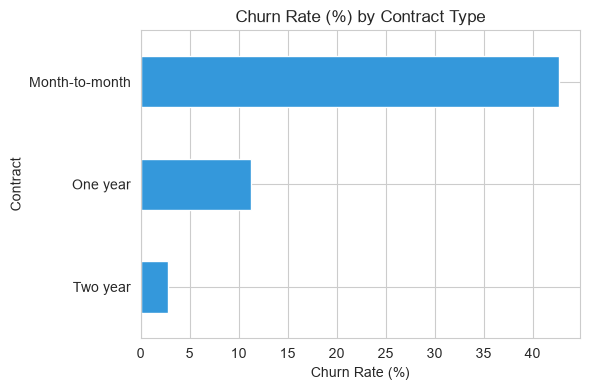

In [28]:
cr = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()*100).sort_values()
plt.figure(figsize=(6,4))
cr.plot(kind='barh', color='#3498DB')
plt.title('Churn Rate (%) by Contract Type')
plt.xlabel('Churn Rate (%)')
plt.tight_layout()
plt.show()


**Interpretation:** Month-to-month customers churn far more than 
one-year or two-year customers. This suggests that customers with 
longer contracts are much more likely to stay, so encouraging 
customers to sign longer contracts could reduce churn.


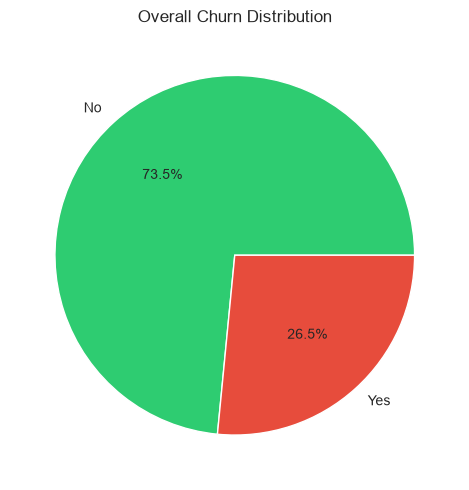

In [29]:
plt.figure(figsize=(5,5))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#2ECC71','#E74C3C'], ylabel='')
plt.title('Overall Churn Distribution')
plt.tight_layout()
plt.show()


**Interpretation:** Overall, 26.5% of customers have churned, 
meaning roughly 1 in 4 customers leaves ABC Communications. 
This is a significant churn rate that justifies focused 
retention efforts.

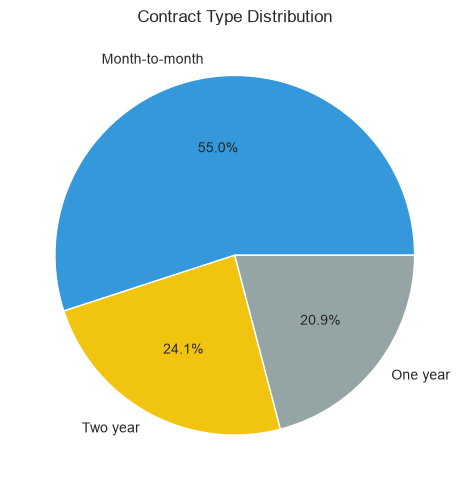

In [30]:
plt.figure(figsize=(5,5))
df['Contract'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#3498DB','#F1C40F','#95A5A6'], ylabel='')
plt.title('Contract Type Distribution')
plt.tight_layout()
plt.show()

**Interpretation:** More than half of ABC Communications' 
customers (55%) are on month-to-month contracts. Combined with 
the earlier finding that month-to-month customers churn the most, 
this means the majority of the customer base is currently in a 
high-risk category for leaving.

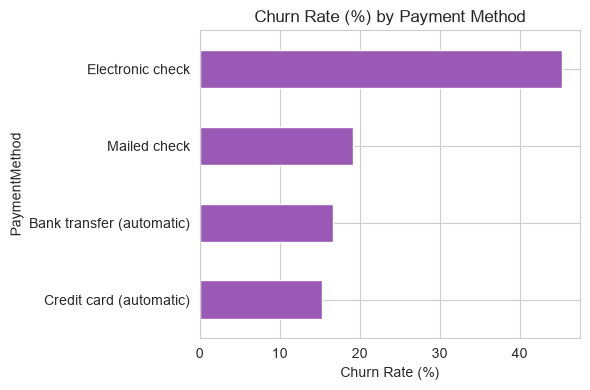

In [31]:
cr2 = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x=='Yes').mean()*100).sort_values()
plt.figure(figsize=(6,4))
cr2.plot(kind='barh', color='#9B59B6')
plt.title('Churn Rate (%) by Payment Method')
plt.xlabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

**Interpretation:** Customers who pay by electronic check churn 
far more than those using automatic payment methods (bank transfer 
or credit card). This suggests that manual, effort-based payment 
methods are linked to higher churn, possibly because customers who 
pay manually re-evaluate their subscription every month, while 
automatic payments create passive loyalty.

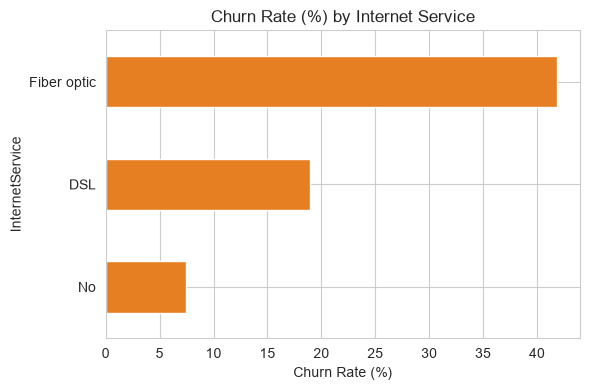

In [32]:
cr3 = df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean()*100).sort_values()
plt.figure(figsize=(6,4))
cr3.plot(kind='barh', color='#E67E22')
plt.title('Churn Rate (%) by Internet Service')
plt.xlabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

**Interpretation:** Fiber optic customers churn significantly more 
than DSL customers, and customers with no internet service churn 
the least. This is surprising since fiber is the premium product — 
it may point to pricing or service quality issues with fiber 
specifically, rather than problems with the technology itself.

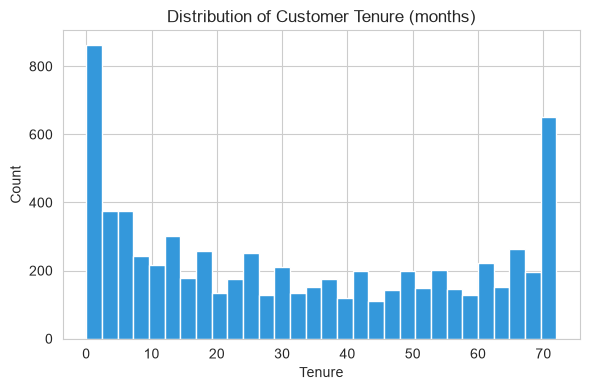

In [33]:
plt.figure(figsize=(6,4))
plt.hist(df['tenure'], bins=30, color='#3498DB', edgecolor='white')
plt.title('Distribution of Customer Tenure (months)')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Interpretation:** Tenure shows two clear groups: a large spike 
of brand-new customers (0-5 months) and another spike of long-term 
customers near 70+ months. This suggests ABC Communications has a 
"sink or swim" customer base — those who make it past the early 
months tend to stay for years, so the first few months are the 
critical window for retention.

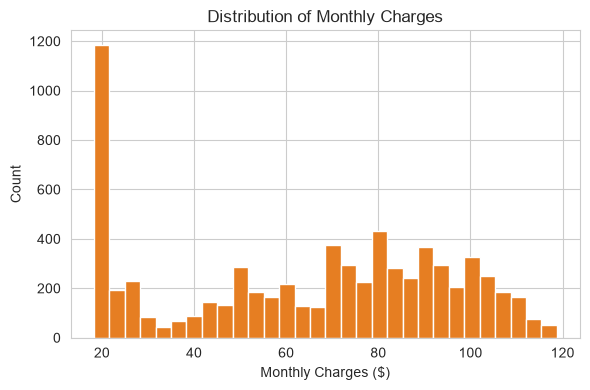

In [34]:
plt.figure(figsize=(6,4))
plt.hist(df['MonthlyCharges'], bins=30, color='#E67E22', edgecolor='white')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Interpretation:** Monthly charges cluster heavily around $20, 
representing customers on basic phone-only plans. There's a 
second, broader cluster between $70-$100, representing customers 
with bundled internet and streaming services. These two groups 
likely have very different retention needs and price sensitivities.

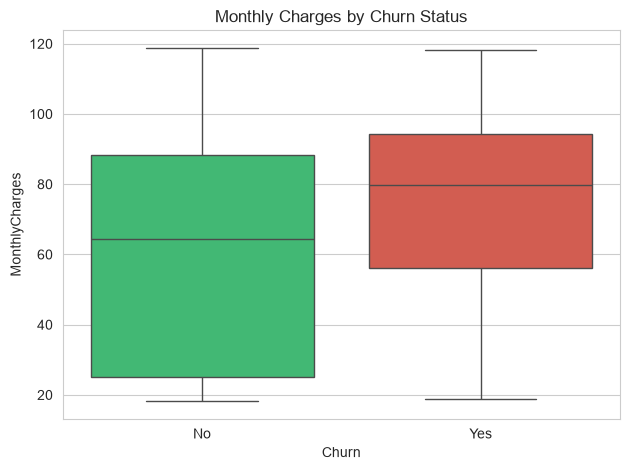

In [35]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette={'Yes':'#E74C3C','No':'#2ECC71'}, legend=False)
plt.title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.show()

**Interpretation:** Customers who churned have a higher median 
monthly charge than those who stayed. This aligns with earlier 
findings — customers paying more (often for fiber/bundled services) 
tend to leave more, suggesting price sensitivity or a value 
mismatch is driving churn among higher-paying customers.

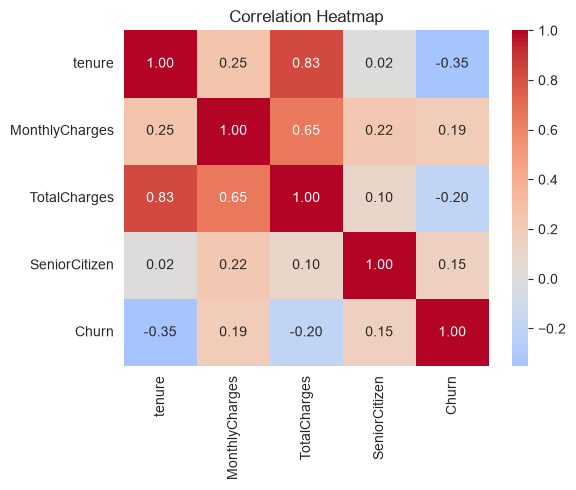

In [36]:
num_df = df[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']].copy()
num_df['Churn'] = (df['Churn']=='Yes').astype(int)
plt.figure(figsize=(6,5))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Interpretation:** Tenure has the strongest negative correlation 
with churn (-0.35) — the longer a customer stays, the less likely 
they are to leave. MonthlyCharges correlates positively with churn 
(+0.19), meaning higher-paying customers churn more. TotalCharges 
correlates negatively (-0.20), but this mostly reflects that it's 
driven by tenure — customers who stay long naturally accumulate 
higher totals.


## Part 4: Business Insights

**Five Insights**
1. Contract type is the strongest churn driver — month-to-month customers churn at over 40%, versus under 3% for two-year contracts.
2. Payment method matters — electronic check users churn far more than customers on automatic payment methods.
3. Fiber optic internet customers churn more than DSL customers, despite fiber being the premium product.
4. Churn is concentrated early — churned customers have much shorter average tenure than retained customers.
5. Higher monthly charges are linked to higher churn, based on both the box plot and the heatmap.

**Three Business Risks**
1. Over half the customer base is on flexible month-to-month contracts, leaving most customers exposed to churn risk.
2. Heavy reliance on electronic check as a payment method sits on the highest-churn payment channel.
3. Fiber optic — the higher-margin premium product — has the highest churn of any internet segment.

**Three Opportunities**
1. Converting month-to-month customers to annual contracts could sharply cut churn.
2. Migrating electronic-check payers to automatic payments could reduce churn in that group significantly.
3. Investigating and improving the fiber optic customer experience could protect high-value revenue.

## Part 5: Business Recommendations

1. Incentivise longer contracts with discounts or loyalty perks for month-to-month customers.
2. Run a campaign encouraging electronic-check users to switch to automatic payments.
3. Investigate fiber optic pricing and service quality specifically, since churn there is unusually high for a premium product.
4. Offer low-cost security/support add-ons to reduce churn among at-risk customers.
5. Build a proactive early-tenure retention programme, since churn risk is highest in the first few months.